In [185]:
# importing packages
import random 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 

%matplotlib inline

In [186]:
# import and vie dataset
import pandas as pd
cust_df = pd.read_csv("iris.csv")
cust_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [187]:
# dropping categorical column 'species'
df = cust_df.drop('species', axis=1)
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [188]:
# normalising dataset
from sklearn.preprocessing import StandardScaler
X = df.values
X = np.nan_to_num(X)
Clus_dataSet = StandardScaler().fit_transform(X)
Clus_dataSet

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [189]:
# k-means clustering using k=3
from sklearn.cluster import KMeans
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(Clus_dataSet)
labels = k_means.labels_
print(labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


In [190]:
# assigning labels to each row
df["Clus_km"] = labels
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,Clus_km
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [191]:
# checking centroid values
df.groupby('Clus_km').mean()

,sepal_length,sepal_width,petal_length,petal_width
Clus_km,,,,
0,5.006000,3.418000,1.464000,0.244000
1,5.801887,2.673585,4.369811,1.413208
2,6.780851,3.095745,5.510638,1.972340


In [192]:
 # confirming data frame shape
Clus_dataSet.shape

(150, 4)

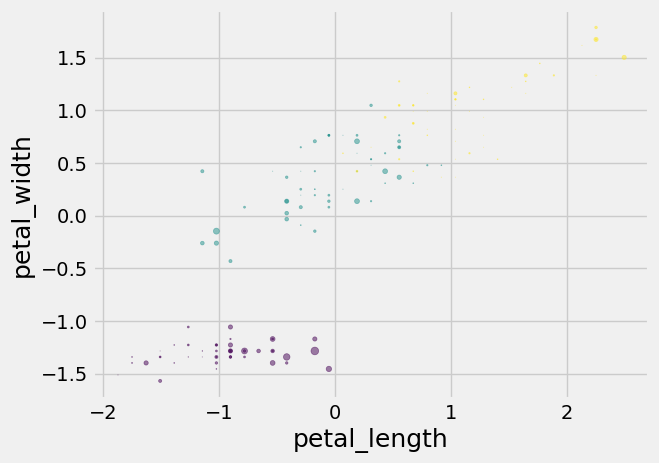

In [193]:
# creating scatter plot where point size is proportional to sepal_width
area = np.pi * ( Clus_dataSet[:, 1])**2  
plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 2], s=area, c=labels.astype(np.float64),  alpha=0.5)
plt.xlabel('petal_length', fontsize=18)
plt.ylabel('petal_width', fontsize=18)

plt.show()

In [194]:
# setting values for k
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, init= "k-means++",n_init= 12,max_iter= 300)
    kmeans.fit(Clus_dataSet)
    sse.append(kmeans.inertia_)

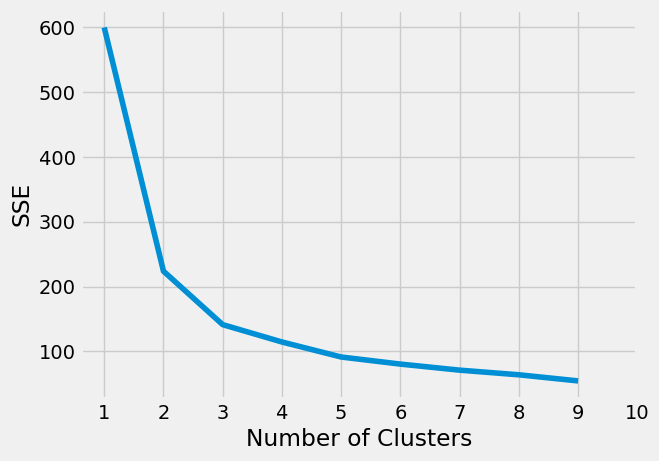

In [195]:
# elbow method to confirm optimal number of clusters
plt.style.use("fivethirtyeight")
plt.plot(range(1, 10), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [196]:
# outputting silhouette coefficients to confirm optimal number of clusters
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_coefficients = []
# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, init= "k-means++",n_init= 12,max_iter= 300)
    kmeans.fit(Clus_dataSet)
    score = silhouette_score(Clus_dataSet, kmeans.labels_)
    silhouette_coefficients.append(score)

silhouette_coefficients

[0.580184463257396,
 0.46214947389312017,
 0.38718196717409115,
 0.3435821075493913,
 0.3290443442233162,
 0.34450126355765764,
 0.3354934855609906,
 0.33335469925305017]

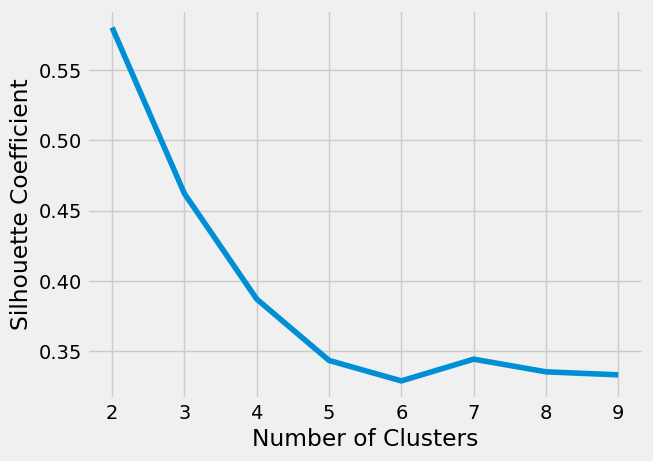

In [197]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 10), silhouette_coefficients)
plt.xticks(range(2, 10))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [198]:
iris = pd.read_csv("iris.csv")

y_true = iris["species"]

df["species"] = y_true

In [199]:
# comparing k-means clusters to original species labels
pd.crosstab(df["Clus_km"], df["species"])

species,setosa,versicolor,virginica
Clus_km,,,
0,50,0,0
1,0,39,14
2,0,11,36
